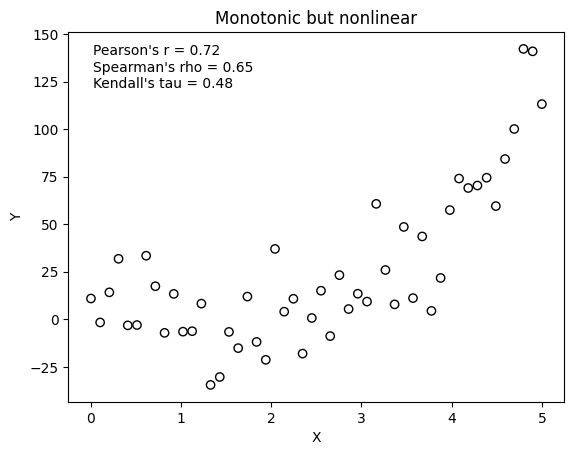

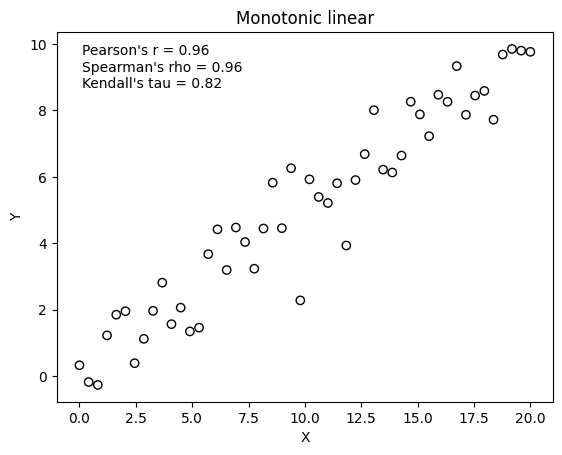

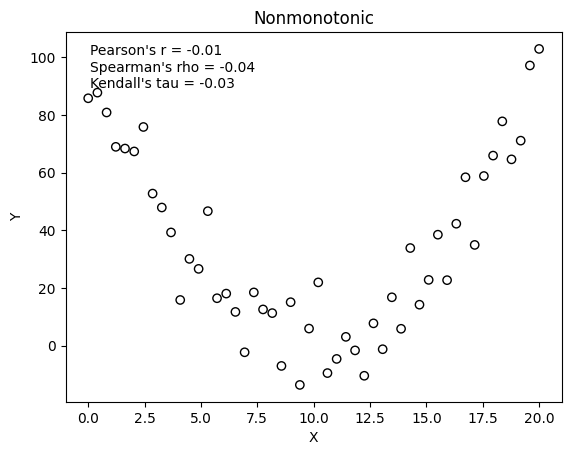

In [1]:
"""
Correlation Examples: Linear vs Monotonic Relationships
Exemplos de Correlação: Relações Lineares vs Monotônicas

This script reproduces classic examples of correlation behavior
based on Helsel & Hirsch (2002), Chapter 8.

Este script reproduz exemplos clássicos de comportamento de correlação
baseados em Helsel & Hirsch (2002), Capítulo 8.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Set random seed for reproducibility
# Define uma semente aleatória para reprodutibilidade
np.random.seed(42)


def compute_correlations(x, y):
    """
    Compute correlation coefficients.
    Calcula os coeficientes de correlação.

    Parameters:
    x, y : arrays
        Input data / Dados de entrada

    Returns:
    tuple
        Pearson, Spearman, Kendall coefficients
        Coeficientes de Pearson, Spearman e Kendall
    """
    p, _ = pearsonr(x, y)
    s, _ = spearmanr(x, y)
    k, _ = kendalltau(x, y)
    return p, s, k


def plot_example(x, y, title, filename):
    """
    Generate scatter plot with correlation coefficients.
    Gera gráfico de dispersão com os coeficientes de correlação.

    Parameters:
    x, y : arrays
        Input data / Dados de entrada
    title : str
        Plot title / Título do gráfico
    filename : str
        File name to save figure / Nome do arquivo para salvar
    """

    # Compute correlations
    # Calcula as correlações
    p, s, k = compute_correlations(x, y)

    # Create plot
    # Cria o gráfico
    plt.figure()
    plt.scatter(x, y, facecolors='none', edgecolors='black')

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)

    # Add text with coefficients (top-left corner)
    # Adiciona texto com os coeficientes (canto superior esquerdo)
    plt.text(
        0.05, 0.85,
        f"Pearson's r = {p:.2f}\nSpearman's rho = {s:.2f}\nKendall's tau = {k:.2f}",
        transform=plt.gca().transAxes
    )

    # Save figure
    # Salva a figura
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()


# ==========================
# Example 1: Monotonic but nonlinear
# Exemplo 1: Monotônica, mas não linear
# ==========================

# Generate data (exponential relationship + noise)
# Gera dados (relação exponencial + ruído)
x1 = np.linspace(0, 5, 50)
y1 = np.exp(x1) + np.random.normal(0, 20, 50)

plot_example(
    x1, y1,
    "Monotonic but nonlinear",
    "fig1_monotonic_nonlinear.png"
)


# ==========================
# Example 2: Linear (monotonic)
# Exemplo 2: Linear (monotônica)
# ==========================

# Generate data (linear relationship + noise)
# Gera dados (relação linear + ruído)
x2 = np.linspace(0, 20, 50)
y2 = 0.5 * x2 + np.random.normal(0, 1, 50)

plot_example(
    x2, y2,
    "Monotonic linear",
    "fig2_linear.png"
)


# ==========================
# Example 3: Nonmonotonic
# Exemplo 3: Não monotônica
# ==========================

# Generate data (quadratic relationship + noise)
# Gera dados (relação quadrática + ruído)
x3 = np.linspace(0, 20, 50)
y3 = (x3 - 10)**2 + np.random.normal(0, 10, 50)

plot_example(
    x3, y3,
    "Nonmonotonic",
    "fig3_nonmonotonic.png"
)